# ✈️ Airline Passenger Satisfaction — SPRINT 2
## Model Building & Evaluation
**Goal:** Build baseline and compare multiple classification models


##  Loading processed file from sprint 1

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,roc_auc_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc)



In [2]:
# ---------- Load Dataset ----------
df = pd.read_csv(r"C:\Users\Shreya R Joshi\Downloads\csv_files\airline_passenger_satisfaction.csv")

In [4]:
# ---------- Data Cleaning ----------
imputer = SimpleImputer(strategy='median')
df["Arrival Delay"] = imputer.fit_transform(df[["Arrival Delay"]])
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
if 'unnamed:_0' in df.columns:
    df.drop('unnamed:_0', axis=1, inplace=True)

for col in ['departure_delay', 'arrival_delay']:
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# ---------- Feature / Target Split ----------
cat_cols = ['gender', 'customer_type', 'type_of_travel', 'class']
num_cols = [
    'id', 'age', 'flight_distance', 'departure_delay', 'arrival_delay',
    'departure_and_arrival_time_convenience', 'ease_of_online_booking',
    'check_in_service', 'online_boarding', 'gate_location',
    'on_board_service', 'seat_comfort', 'leg_room_service',
    'cleanliness', 'food_and_drink', 'in_flight_service',
    'in_flight_wifi_service', 'in_flight_entertainment', 'baggage_handling'
]

le_y = LabelEncoder()
y_enc = le_y.fit_transform(df['satisfaction'])
X = df.drop('satisfaction', axis=1)

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"✅ Setup complete  |  Train: {X_train_proc.shape}  |  Test: {X_test_proc.shape}")
print(f"Target classes: {le_y.classes_}")

✅ Setup complete  |  Train: (103904, 28)  |  Test: (25976, 28)
Target classes: ['Neutral or Dissatisfied' 'Satisfied']



## Step 1 — Baseline Model: Logistic Regression

LOGISTIC REGRESSION — Baseline
Train Accuracy: 0.8750
Test  Accuracy: 0.8781
Precision     : 0.8726
Recall        : 0.8424
F1 Score      : 0.8572

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.88      0.91      0.89     14690
              Satisfied       0.87      0.84      0.86     11286

               accuracy                           0.88     25976
              macro avg       0.88      0.87      0.88     25976
           weighted avg       0.88      0.88      0.88     25976



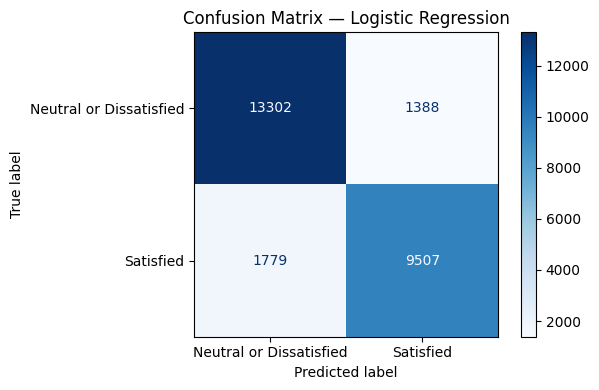

In [5]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_proc, y_train)
y_pred_lr = lr_model.predict(X_test_proc)

print("=" * 55)
print("LOGISTIC REGRESSION — Baseline")
print("=" * 55)
print(f"Train Accuracy: {lr_model.score(X_train_proc, y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le_y.classes_))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=le_y.classes_, cmap='Blues', ax=ax)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig('../data/cm_logistic.png', dpi=100)
plt.show()

## Step 2 — Train Multiple Models

### 2a. Decision Tree Classifier

DECISION TREE
Train Accuracy: 1.0000
Test  Accuracy: 0.9468
Precision     : 0.9390
Recall        : 0.9385
F1 Score      : 0.9388
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.95      0.95      0.95     14690
              Satisfied       0.94      0.94      0.94     11286

               accuracy                           0.95     25976
              macro avg       0.95      0.95      0.95     25976
           weighted avg       0.95      0.95      0.95     25976



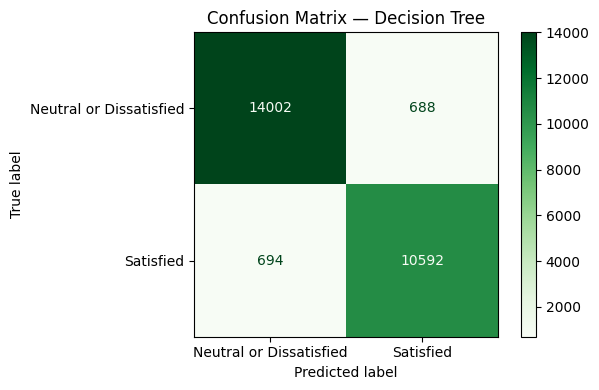

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_proc, y_train)
y_pred_dt = dt_model.predict(X_test_proc)

print("=" * 55)
print("DECISION TREE")
print("=" * 55)
print(f"Train Accuracy: {dt_model.score(X_train_proc, y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=le_y.classes_))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt,
    display_labels=le_y.classes_, cmap='Greens', ax=ax)
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.savefig('../data/cm_decision_tree.png', dpi=100)
plt.show()

### 2b. Random Forest Classifier

RANDOM FOREST
Train Accuracy: 1.0000
Test  Accuracy: 0.9656
Precision     : 0.9759
Recall        : 0.9441
F1 Score      : 0.9597
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.98      0.94      0.96     11286

               accuracy                           0.97     25976
              macro avg       0.97      0.96      0.96     25976
           weighted avg       0.97      0.97      0.97     25976



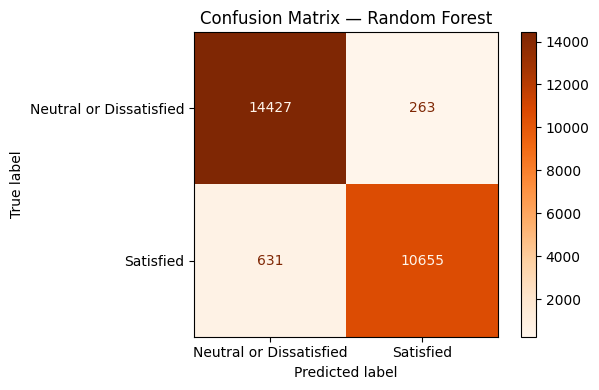

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_proc, y_train)
y_pred_rf = rf_model.predict(X_test_proc)

print("=" * 55)
print("RANDOM FOREST")
print("=" * 55)
print(f"Train Accuracy: {rf_model.score(X_train_proc, y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=le_y.classes_))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=le_y.classes_, cmap='Oranges', ax=ax)
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig('../data/cm_random_forest.png', dpi=100)
plt.show()

### 2c. Gradient Boosting Classifier

GRADIENT BOOSTING
Train Accuracy: 0.9444
Test  Accuracy: 0.9452
Precision     : 0.9498
Recall        : 0.9226
F1 Score      : 0.9360
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.94      0.96      0.95     14690
              Satisfied       0.95      0.92      0.94     11286

               accuracy                           0.95     25976
              macro avg       0.95      0.94      0.94     25976
           weighted avg       0.95      0.95      0.95     25976



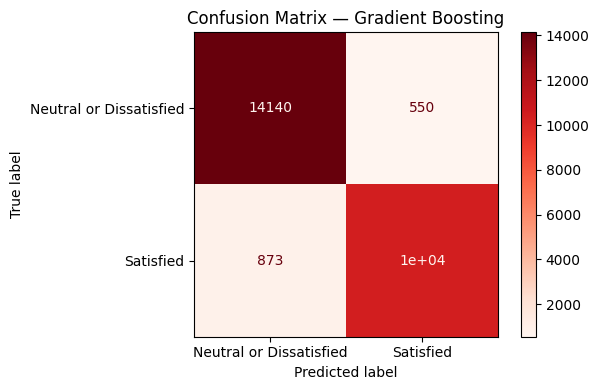

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_proc, y_train)
y_pred_gb = gb_model.predict(X_test_proc)

print("=" * 55)
print("GRADIENT BOOSTING")
print("=" * 55)
print(f"Train Accuracy: {gb_model.score(X_train_proc, y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb, target_names=le_y.classes_))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb,
    display_labels=le_y.classes_, cmap='Reds', ax=ax)
ax.set_title("Confusion Matrix — Gradient Boosting")
plt.tight_layout()
plt.savefig('../data/cm_gradient_boosting.png', dpi=100)
plt.show()

### 2d. Naïve Bayes

NAÏVE BAYES (Gaussian)
Train Accuracy: 0.8491
Test  Accuracy: 0.8529
Precision     : 0.8354
Recall        : 0.8237
F1 Score      : 0.8295
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.87      0.88      0.87     14690
              Satisfied       0.84      0.82      0.83     11286

               accuracy                           0.85     25976
              macro avg       0.85      0.85      0.85     25976
           weighted avg       0.85      0.85      0.85     25976



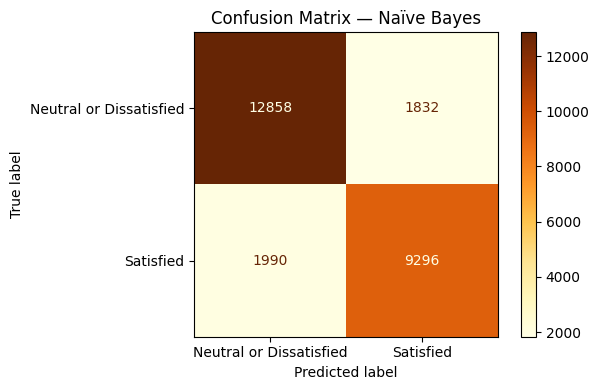

In [13]:
from sklearn.naive_bayes import GaussianNB
import scipy.sparse

X_train_dense = X_train_proc.toarray() if scipy.sparse.issparse(X_train_proc) else X_train_proc
X_test_dense  = X_test_proc.toarray()  if scipy.sparse.issparse(X_test_proc)  else X_test_proc

nb_model = GaussianNB()
nb_model.fit(X_train_dense, y_train)
y_pred_nb = nb_model.predict(X_test_dense)

print("=" * 55)
print("NAÏVE BAYES (Gaussian)")
print("=" * 55)
print(f"Train Accuracy: {nb_model.score(X_train_dense, y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, target_names=le_y.classes_))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb,
    display_labels=le_y.classes_, cmap='YlOrBr', ax=ax)
ax.set_title("Confusion Matrix — Naïve Bayes")
plt.tight_layout()
plt.savefig('../data/cm_naive_bayes.png', dpi=100)
plt.show()


## Step 3 — Model Evaluation Summary

In [14]:
models_dict = {
    'Logistic Regression': (lr_model,  y_pred_lr,  X_train_proc, X_test_proc),
    'Decision Tree'      : (dt_model,  y_pred_dt,  X_train_proc, X_test_proc),
    'Random Forest'      : (rf_model,  y_pred_rf,  X_train_proc, X_test_proc),
    'Gradient Boosting'  : (gb_model,  y_pred_gb,  X_train_proc, X_test_proc),
    'Naïve Bayes'        : (nb_model,  y_pred_nb,  X_train_dense, X_test_dense),
}

rows = []
for name, (model, y_pred, Xtr, Xte) in models_dict.items():
    train_acc = model.score(Xtr, y_train)
    test_acc  = model.score(Xte, y_test)
    rows.append({
        'Model'      : name,
        'Train Acc'  : round(train_acc, 4),
        'Test Acc'   : round(test_acc,  4),
        'Precision'  : round(precision_score(y_test, y_pred), 4),
        'Recall'     : round(recall_score(y_test, y_pred), 4),
        'F1 Score'   : round(f1_score(y_test, y_pred), 4),
        'Overfitting': 'Yes' if abs(train_acc - test_acc) > 0.05 else 'No'
    })

summary_df = pd.DataFrame(rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print("\nModel Comparison Table:")
display(summary_df)


Model Comparison Table:


,Model,Train Acc,Test Acc,Precision,Recall,F1 Score,Overfitting
0,Random Forest,1.0000,0.9656,0.9759,0.9441,0.9597,No
1,Decision Tree,1.0000,0.9468,0.9390,0.9385,0.9388,Yes
2,Gradient Boosting,0.9444,0.9452,0.9498,0.9226,0.9360,No
3,Logistic Regression,0.8750,0.8781,0.8726,0.8424,0.8572,No
4,Naïve Bayes,0.8491,0.8529,0.8354,0.8237,0.8295,No



##  Step 4 — Overfitting & Underfitting Check

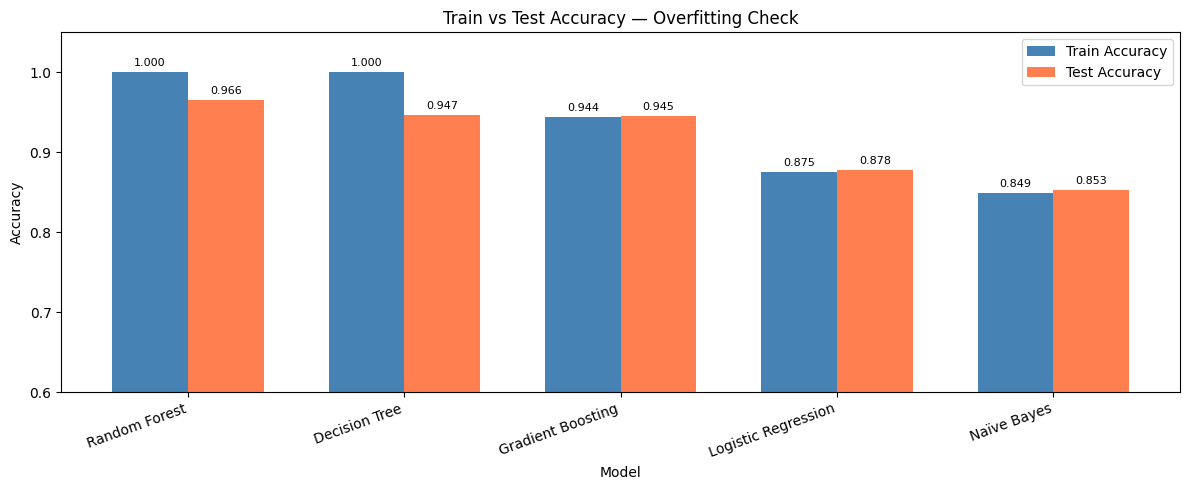

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary_df))
width = 0.35

bars1 = ax.bar(x - width/2, summary_df['Train Acc'], width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, summary_df['Test Acc'],  width, label='Test Accuracy',  color='coral')
ax.set_xlabel('Model'); ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy — Overfitting Check')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=20, ha='right')
ax.set_ylim(0.6, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('../data/overfitting_check.png', dpi=100)
plt.show()


## Step 5 — ROC-AUC Curves (All Models)

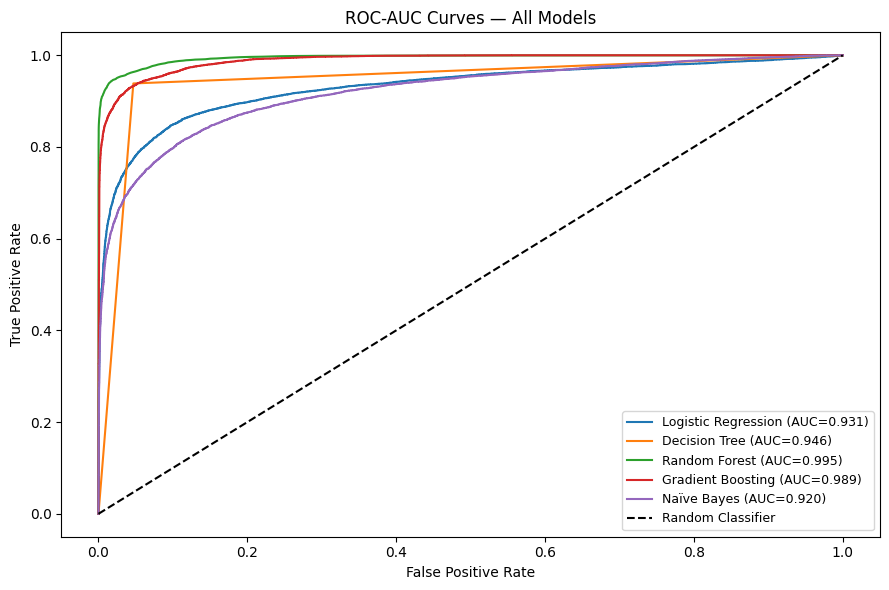

In [16]:
plt.figure(figsize=(9, 6))

roc_models = {
    'Logistic Regression': (lr_model,  X_test_proc),
    'Decision Tree'      : (dt_model,  X_test_proc),
    'Random Forest'      : (rf_model,  X_test_proc),
    'Gradient Boosting'  : (gb_model,  X_test_proc),
    'Naïve Bayes'        : (nb_model,  X_test_dense),
}

for name, (model, Xte) in roc_models.items():
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/roc_auc_curves.png', dpi=100)
plt.show()


## Step 6 — 5-Fold Cross-Validation

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': (lr_model,  X_train_proc),
    'Decision Tree'      : (dt_model,  X_train_proc),
    'Random Forest'      : (rf_model,  X_train_proc),
    'Gradient Boosting'  : (gb_model,  X_train_proc),
    'Naïve Bayes'        : (nb_model,  X_train_dense),
}

print(f"{'Model':<25} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 47)

cv_results = {}
for name, (model, Xtr) in cv_models.items():
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")


Model                        CV Mean     CV Std
-----------------------------------------------
Logistic Regression           0.8533     0.0025
Decision Tree                 0.9376     0.0011
Random Forest                 0.9584     0.0007
Gradient Boosting             0.9341     0.0008
Naïve Bayes                   0.8245     0.0021



## Step 7 — Feature Importance (Random Forest)

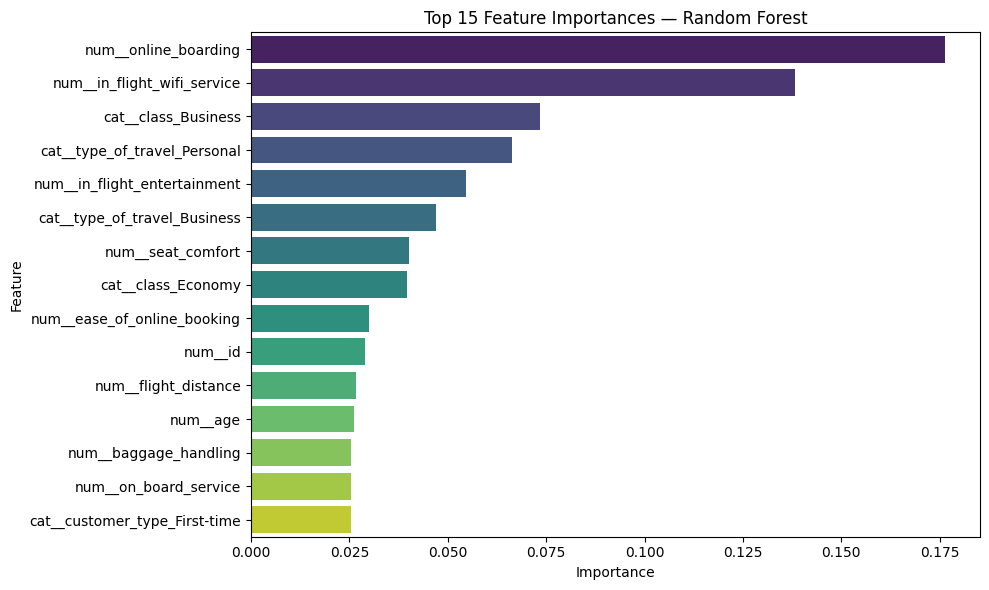

In [19]:
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=100)
plt.show()

---
## ✅ Sprint 2 — Final Summary

In [20]:
best_row = summary_df.iloc[0]
print("=" * 55)
print("SPRINT 2 DELIVERABLES")
print("=" * 55)
print(f"✅ Models trained  : {len(models_dict)}")
print(f"✅ Best model      : {best_row['Model']}")
print(f"   Test Accuracy   : {best_row['Test Acc']}")
print(f"   F1 Score        : {best_row['F1 Score']}")
print(f"   Overfitting     : {best_row['Overfitting']}")
print("=" * 55)
print("\nFull Comparison:")
display(summary_df)
print("\n➡️  Proceed to Sprint 3 → Optimization & Final Model")

SPRINT 2 DELIVERABLES
✅ Models trained  : 5
✅ Best model      : Random Forest
   Test Accuracy   : 0.9656
   F1 Score        : 0.9597
   Overfitting     : No

Full Comparison:


,Model,Train Acc,Test Acc,Precision,Recall,F1 Score,Overfitting
0,Random Forest,1.0000,0.9656,0.9759,0.9441,0.9597,No
1,Decision Tree,1.0000,0.9468,0.9390,0.9385,0.9388,Yes
2,Gradient Boosting,0.9444,0.9452,0.9498,0.9226,0.9360,No
3,Logistic Regression,0.8750,0.8781,0.8726,0.8424,0.8572,No
4,Naïve Bayes,0.8491,0.8529,0.8354,0.8237,0.8295,No



➡️  Proceed to Sprint 3 → Optimization & Final Model


# Sprint 3
**Optimization & Final Model**

## Step 8 — Hyperparameter Tuning

## 3a. Random Forest — GridSearchCV

In [22]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_proc, y_train)

print(f"✅ RF Best Params: {rf_grid.best_params_}")
print(f"   Best CV F1    : {rf_grid.best_score_:.4f}")
best_rf = rf_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ RF Best Params: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV F1    : 0.9588


## 3b. Gradient Boosting — RandomizedSearchCV

In [23]:
from sklearn.model_selection import RandomizedSearchCV

gb_param_dist = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5, 6],
    'subsample'     : [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=42, verbose=1
)
gb_random.fit(X_train_proc, y_train)

print(f"✅ GB Best Params : {gb_random.best_params_}")
print(f"   Best CV F1     : {gb_random.best_score_:.4f}")
best_gb = gb_random.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ GB Best Params : {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 6, 'learning_rate': 0.1}
   Best CV F1     : 0.9591


## 3c. Logistic Regression — GridSearchCV

In [24]:
lr_param_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_proc, y_train)

print(f"✅ LR Best Params : {lr_grid.best_params_}")
print(f"   Best CV F1     : {lr_grid.best_score_:.4f}")
best_lr = lr_grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ LR Best Params : {'C': 0.1, 'solver': 'liblinear'}
   Best CV F1     : 0.8535


# Step 9 — Build Final Model (Best Estimator)

In [28]:
# Compare tuned models
tuned_models = {
    'Random Forest (Tuned)'      : best_rf,
    'Gradient Boosting (Tuned)'  : best_gb,
    'Logistic Regression (Tuned)': best_lr,
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_proc)
    tuned_results.append({
        'Model'    : name,
        'Test Acc' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, model.predict_proba(X_test_proc)[:,1]), 4)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print("Tuned Model Comparison:")
display(tuned_df)

# Select best model
best_model_name = tuned_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]
print(f"\n🏆 Best Final Model: {best_model_name}")

Tuned Model Comparison:


,Model,Test Acc,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting (Tuned),0.9670,0.9744,0.9489,0.9615,0.9958
1,Random Forest (Tuned),0.9662,0.9762,0.9452,0.9604,0.9948
2,Logistic Regression (Tuned),0.8782,0.8728,0.8425,0.8574,0.9308



🏆 Best Final Model: Gradient Boosting (Tuned)


## Step 10 - Build final end-to-end pipeline

FINAL MODEL EVALUATION
Model    : Gradient Boosting (Tuned)
Accuracy : 0.9670
Precision: 0.9744
Recall   : 0.9489
F1 Score : 0.9615
ROC-AUC  : 0.9958

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.95      0.96     11286

               accuracy                           0.97     25976
              macro avg       0.97      0.96      0.97     25976
           weighted avg       0.97      0.97      0.97     25976



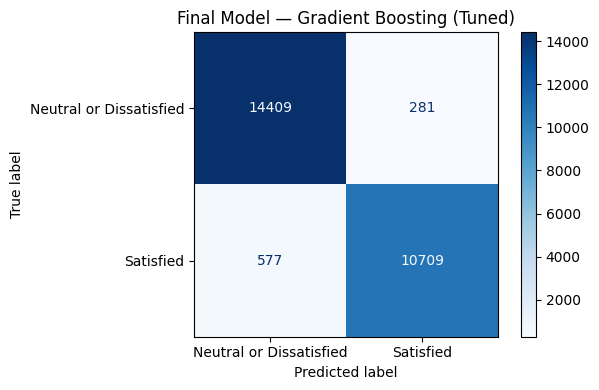

In [29]:

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Re-train on unprocessed X (pipeline handles preprocessing internally)
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)
print("=" * 55)
print("FINAL MODEL EVALUATION")
print("=" * 55)
print(f"Model    : {best_model_name}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, final_pipeline.predict_proba(X_test)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=le_y.classes_))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=le_y.classes_, cmap='Blues', ax=ax
)
ax.set_title(f'Final Model — {best_model_name}')
plt.tight_layout()
plt.savefig('../data/final_model_cm.png', dpi=100)
plt.show()

## Final Evaluation on Unseen Test Data

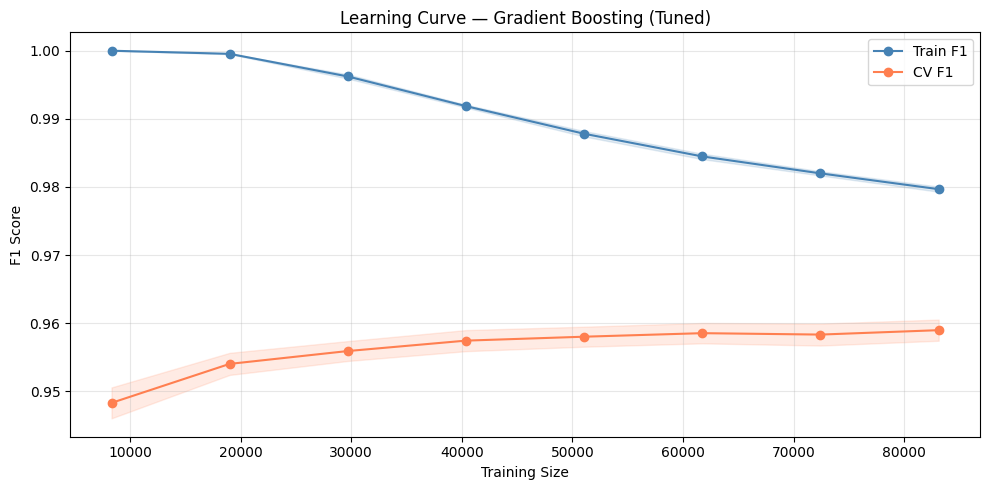

In [30]:
from sklearn.model_selection import learning_curve

# Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    final_pipeline, X_train, y_train,
    cv=5, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train F1')
plt.plot(train_sizes, test_scores.mean(axis=1),  'o-', color='coral',     label='CV F1')
plt.fill_between(train_sizes,
    train_scores.mean(1) - train_scores.std(1),
    train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='steelblue')
plt.fill_between(train_sizes,
    test_scores.mean(1) - test_scores.std(1),
    test_scores.mean(1) + test_scores.std(1), alpha=0.15, color='coral')
plt.xlabel('Training Size'); plt.ylabel('F1 Score')
plt.title(f'Learning Curve — {best_model_name}')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/learning_curve.png', dpi=100)
plt.show()

## Model Serialization with Pickle


In [32]:
# Define service_cols (add this at the top of the cell or just before feature_meta)
service_cols = [
    'departure_and_arrival_time_convenience', 'ease_of_online_booking',
    'check_in_service', 'online_boarding', 'gate_location',
    'on_board_service', 'seat_comfort', 'leg_room_service',
    'cleanliness', 'food_and_drink', 'in_flight_service',
    'in_flight_wifi_service', 'in_flight_entertainment', 'baggage_handling'
]

# Save the complete pipeline (preprocessor + model)
with open('../models/final_model_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

# Save label encoder
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le_y, f)

# Save feature metadata
feature_meta = {
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'service_cols': service_cols,
    'model_name': best_model_name,
    'test_accuracy': accuracy_score(y_test, y_pred_final),
    'test_f1': f1_score(y_test, y_pred_final),
    'classes': list(le_y.classes_)
}
with open('../models/feature_meta.pkl', 'wb') as f:
    pickle.dump(feature_meta, f)

# Verify model loads correctly
with open('../models/final_model_pipeline.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
verify_pred = loaded_model.predict(X_test[:5])

print("✅ All files saved successfully!")
print("  📦 final_model_pipeline.pkl")
print("  📦 label_encoder.pkl")
print("  📦 feature_meta.pkl")
print(f"\n🔍 Verification prediction: {verify_pred}")

✅ All files saved successfully!
  📦 final_model_pipeline.pkl
  📦 label_encoder.pkl
  📦 feature_meta.pkl

🔍 Verification prediction: [0 0 1 0 1]
